In [101]:
import os
import nibabel as nib
import numpy as np
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import cv2
import random
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

In [102]:

def transform_tumor(tumor_mask, gen_img, scale_factor: float, target_center: np.array):
    # Find the center of the tumor in tumor_mask
    tumor_indices = np.argwhere(tumor_mask > 0)
    if tumor_indices.size == 0:
        raise ValueError("No tumor found in mask.")
    tumor_center = np.mean(tumor_indices, axis=0).astype(int)  # (z, y, x)

    # Extract the bounding box of the tumor
    min_idx = tumor_indices.min(axis=0)
    max_idx = tumor_indices.max(axis=0) + 1
    tumor_crop = tumor_mask[min_idx[0]:max_idx[0], min_idx[1]:max_idx[1], min_idx[2]:max_idx[2]]

    # Scale the tumor crop in 3D
    zoom_factors = [scale_factor, scale_factor, scale_factor]
    scaled_tumor = zoom(tumor_crop, zoom_factors, order=0)  # nearest neighbor

    # Find new center after scaling
    scaled_center = np.array(scaled_tumor.shape) // 2

    # Compute placement indices
    start = target_center - scaled_center
    end = start + np.array(scaled_tumor.shape)

    # Ensure indices are within bounds
    start = np.maximum(start, 0)
    end = np.minimum(end, gen_img.shape)
    insert_slices = tuple(slice(start[i], end[i]) for i in range(3))
    tumor_slices = tuple(slice(0, end[i] - start[i]) for i in range(3))

    # Place the scaled tumor in new_mask
    new_mask = np.zeros_like(gen_img)
    new_mask[insert_slices] = scaled_tumor[tumor_slices]
    return new_mask

def get_z_range(tumor_mask):
    tumor_indices = np.argwhere(tumor_mask > 0)
    if tumor_indices.size == 0:
        raise ValueError("No tumor found in mask.")
    min_idx = tumor_indices.min(axis=0)
    max_idx = tumor_indices.max(axis=0) + 1
    z_start = min_idx[0]
    z_end = max_idx[0]
    return z_start, z_end

In [103]:

# Choose 6 evenly spaced slices between z_min and z_max
def visualize_generated(gen_img, new_mask):
    z_min, z_max = get_z_range(new_mask)  
    num_slices = 16
    z_indices = np.linspace(z_min, z_max + 20, num_slices, dtype=int)

    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()

    for i, z in enumerate(z_indices):
        axes[i].imshow(gen_img[:, :, z], cmap='jet')
        axes[i].imshow(new_mask[:, :, z], cmap='autumn', alpha=0.5)
        axes[i].set_title(f"Slice z={z}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def save_gif(gen_img, output_mask, new_mask, image_num):
    num_slices = gen_img.shape[2]

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))

    def update(frame):
        for ax in axes:
            ax.clear()
            ax.axis('off')
        axes[0].imshow(gen_img[:, :, frame], cmap='jet')
        axes[0].set_title(f'gen_mask (z={frame})')
        axes[1].imshow(output_mask[:, :, frame], cmap='jet')
        axes[1].set_title(f'output_mask (z={frame})')
        axes[2].imshow(new_mask[:, :, frame], cmap='jet')
        axes[2].set_title(f'new_mask (z={frame})')

    anim = FuncAnimation(fig, update, frames=num_slices, interval=100)
    gif_path = f"results/gen_gefs/gen_vs_output{image_num:02d}.gif"
    anim.save(gif_path, writer='imagemagick', fps=10)
    plt.close(fig)
    print(f"GIF saved at {gif_path}")

In [ ]:
### load data
image_num = 1
volume_num = random.randint(1, 352)
gen_img_path = f'data/training_label_maps/training_seg_{image_num:02d}.nii.gz'
gen_img = nib.load(gen_img_path).get_fdata()
tumor_path = f"data/Brats_resize/masks/volume_{volume_num:03d}_mask.nii.gz"
tumor_mask = nib.load(tumor_path).get_fdata()
tumor_mask = np.where(tumor_mask >100, tumor_mask +900, 0)

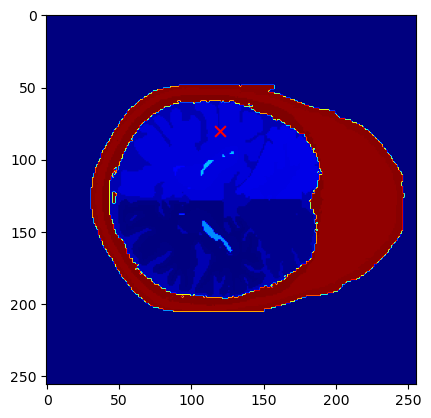

In [53]:
## visualize the center of the tumor
z_slice = 100
center = np.array([80, 120, z_slice])
plt.imshow(gen_img[:, :, z_slice], cmap='jet')
plt.scatter(center[1], center[0], c='red', s=60, marker='x')
plt.show()

In [54]:
new_mask = transform_tumor(tumor_mask, gen_img, scale_factor=0.7, target_center=center)

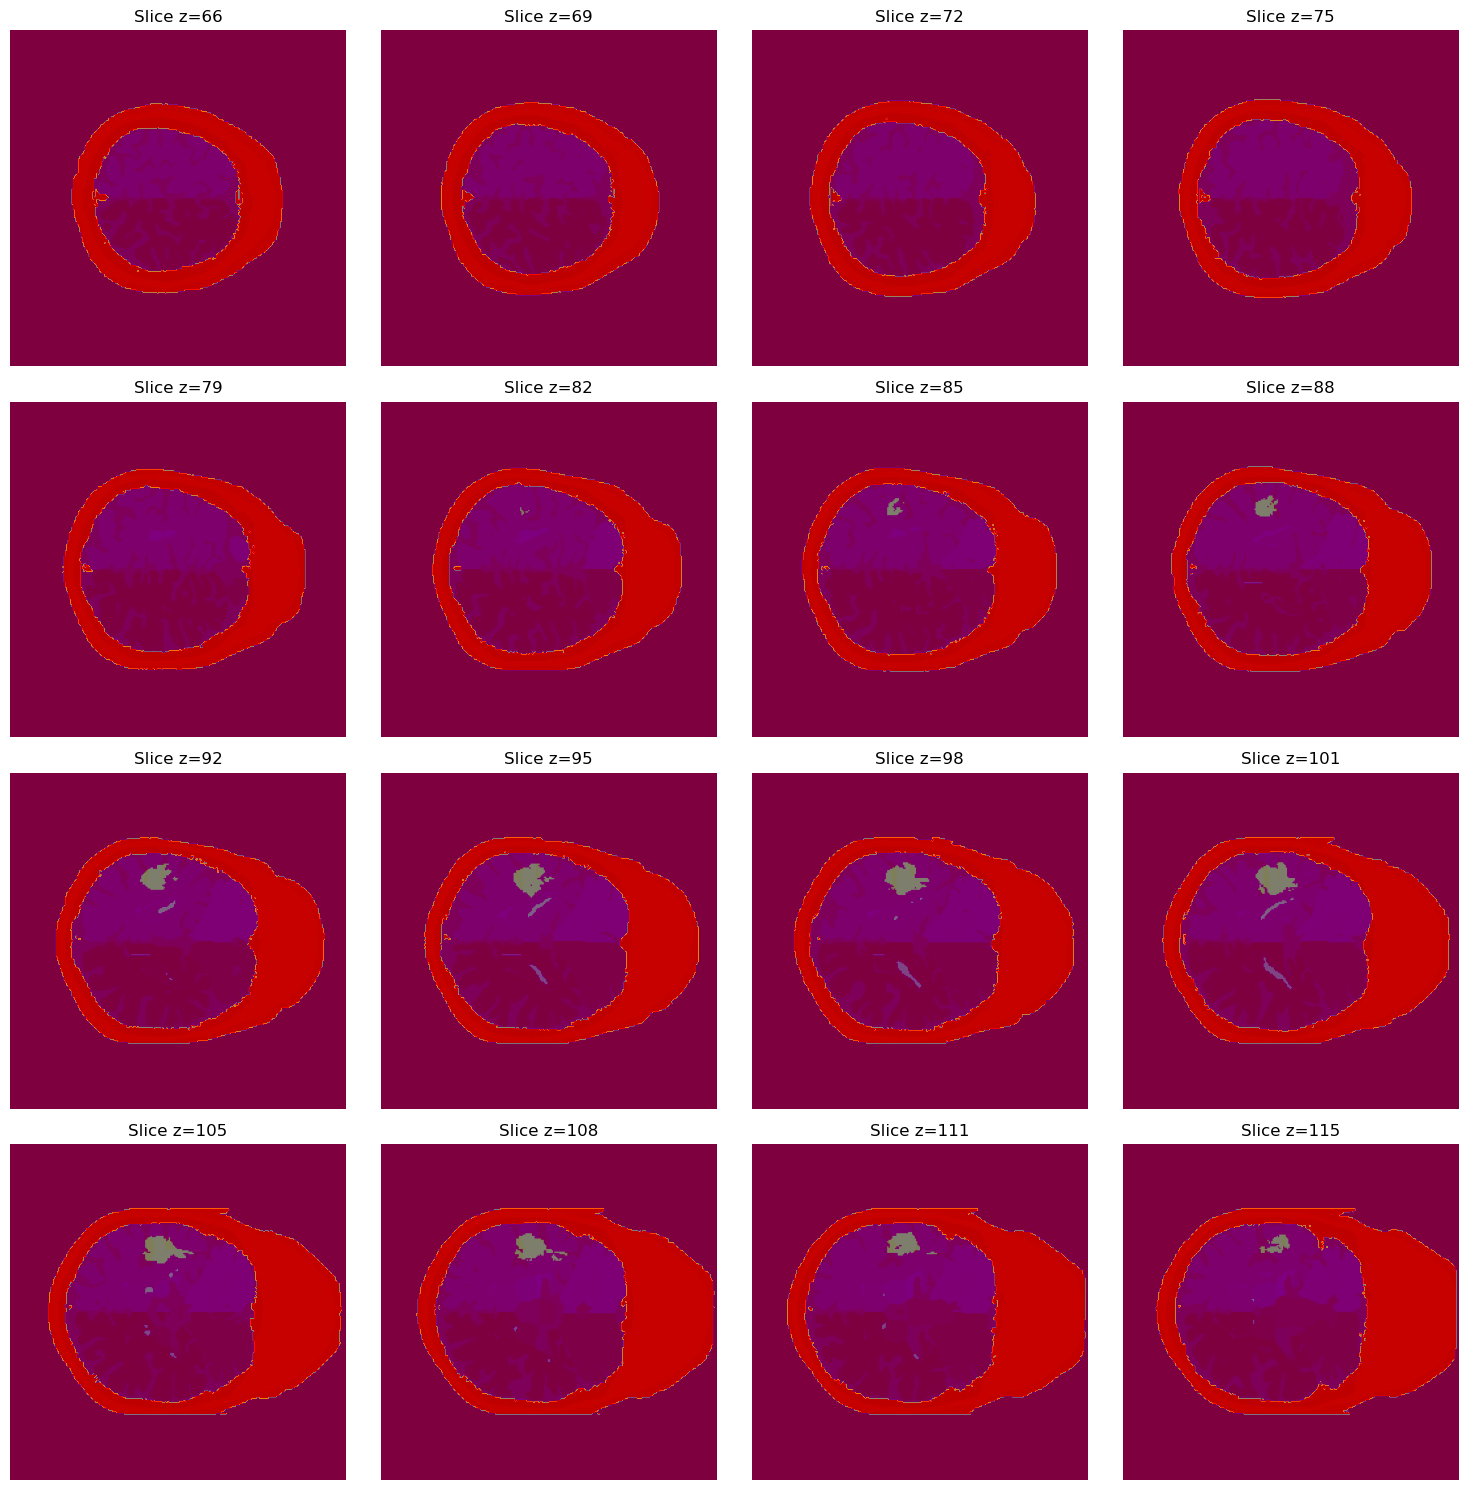

In [ ]:
visualize_generated(gen_img, new_mask)


In [ ]:
save_gif(gen_img, tumor_mask, new_mask)

In [ ]:
output_mask = np.where(new_mask > 0, new_mask, gen_img )
output_mask = np.where(gen_img == 0, gen_img, output_mask)


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Assume gen_mask and output_mask are 3D numpy arrays of the same shape


In [ ]:
output_folder = "results/tumor_labels_maps"

In [ ]:
nib.save(nib.Nifti1Image(output_mask, nii_data.affine), os.path.join(output_folder, f"output_mask_{num}.nii.gz"))